# 12.6 相鄰頻率怎麼合成少量頻帶？


頻譜每框有 201 個頻率格，想用 16 個較寬區段表示能量。讓每個區段用一排非負權重加總，本課配方中間權重最大、兩側逐漸降至0，畫成三角形；相鄰三角形可以重疊，共同接收同一頻率。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

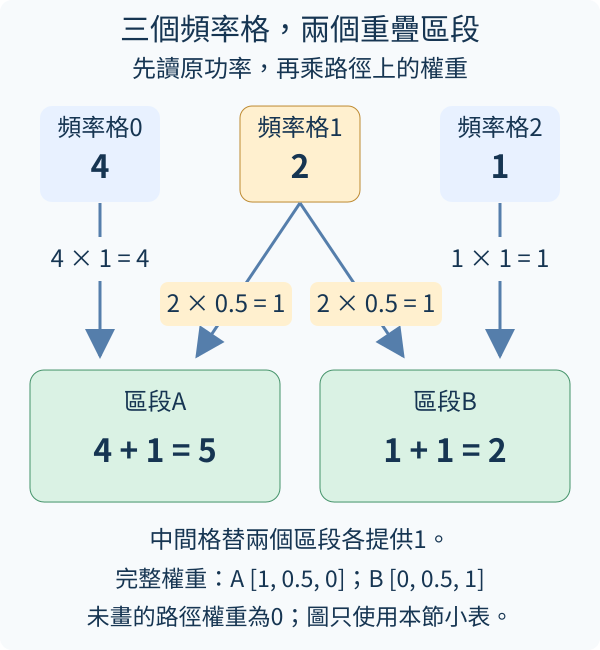

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/multimodal_overlapping_bands.svg")))

這種依 mel 尺度配置的頻帶，低頻安排得較密、高頻較疏。常用換算為 `mel＝2595×log10(1＋f／700)`；0、700、2100 Hz 約為 0、781、1562 mel。Hz 間隔越往上越大，mel 間隔仍可相同。

程式先用全 1 的示範功率表，代表 201 個頻率格、3 個時間框，核對合成後的形狀與權重是否非負。


In [3]:
import torch
from tiny_perceptron.multimodal import mel_filter_bank

bank = mel_filter_bank(bands=16)
power = torch.ones(201, 3)
mel_power = bank @ power
print("權重表", tuple(bank.shape))
print("合成後", tuple(mel_power.shape))
print("權重非負", bool((bank >= 0).all()))

權重表 (16, 201)
合成後 (16, 3)
權重非負 True


權重表 `(16,201)`，每列負責一個頻帶；功率表 `(201,3)` 表示三個時間框。矩陣相乘得到 `(16,3)`，時間框沒有被平均掉。權重非負印 True，說明本配方以加權相加組合功率。

手算只取三格功率 `[4,2,1]`：若第一帶權重 `[1,0.5,0]`，得到 5；第二帶權重 `[0,0.5,1]`，得到 2。同一個中間格 2 各以一半貢獻，兩帶便有重疊。這個小算例展示相乘，不是實際 16 帶的權重值。

頻帶變少會合併差異，因此不能由 16 帶唯一還原所有 201 格。mel 配方是固定的聲音前處理；後面自行訓練的入口才學如何利用它答題。練習把 bands 改成 32，預期權重表 `(32,201)`、輸出 `(32,3)`，並保持三個時間框。

<details>
<summary>回顧與查證</summary>

可回顧：[12.5頻率格與功率](https://birdhackor.github.io/tiny-perceptron-vlm/12.5.html)、[W.5加權矩陣](https://birdhackor.github.io/tiny-perceptron-vlm/first-steps.html#W.5)。

</details>
